# CNN from Scratch on CIFAR-10 — Notebook 2/4

## Class: Technical Aspects of CNNs in PyTorch

### Objective

Train a **complete CNN** from scratch on CIFAR-10, applying **all technical best practices** used by ML engineers in production: data augmentation, BatchNorm, learning rate scheduler, best model checkpointing, TensorBoard monitoring, and error analysis via confusion matrix.

### What we will cover

1. Setup (seed, device, hyperparameters).
2. CIFAR-10 Dataset with **different `transforms` for train and test** (augmentation only in training).
3. Batch visualization.
4. Custom CNN using `nn.Module` (3 conv-bn-relu-pool blocks + FC) — commenting on the **shape at each step**.
5. Model inspection with `torchinfo`.
6. Separate loops for training (`model.train()`) and validation (`model.eval()` + `torch.no_grad()`).
7. `SummaryWriter` (TensorBoard) for tracking loss/accuracy per epoch.
8. `CosineAnnealingLR` scheduler.
9. Checkpointing the **best** model based on val_acc.
10. Training curves and test confusion matrix.
11. Visualizing **model errors**.
12. Final exercise: building a deeper network.

### Prerequisites
- Notebook 1 (fundamentals of Conv2d).
- Basic PyTorch training loop.

## 1. Imports + Reproducibility

We set seeds in **three libraries**: `torch`, `numpy`, and Python's random. This ensures that initial weights, `DataLoader` shuffling, and any internal randomness are reproducible.

We also enable `cudnn.benchmark = True` to let CUDA choose the fastest algorithms — it's worth it for long training runs. If you need **total determinism**, use `False` + `torch.use_deterministic_algorithms(True)` (we'll see this in Notebook 4).

In [1]:
# Fix: Install missing dependencies if not found
try:
    import seaborn as sns
    import sklearn
except ImportError:
    import subprocess
    import sys
    print("Installing missing dependencies (seaborn, scikit-learn)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "scikit-learn", "--break-system-packages"])
    import seaborn as sns
    import sklearn

import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
# TensorBoard removed (protobuf 6.x conflict). We use a dict + matplotlib.

import torchvision
import torchvision.transforms as T

from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Lets cuDNN choose the fastest algorithms for our input shape
torch.backends.cudnn.benchmark = True

print(f"PyTorch: {torch.__version__}")

PyTorch: 2.12.0


## 2. Device

We detect the available GPU. We support:
- **CUDA**: NVIDIA GPUs (Colab, Linux).
- **MPS**: Apple Silicon integrated GPU (M1/M2/M3 Mac).
- **CPU**: fallback.

In [2]:
def selecionar_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    return torch.device("cpu")

device = selecionar_device()
print(f"Using device: {device}")

Using device: mps


## 3. Hyperparameters

We centralize hyperparameters in one place — makes it easier to tweak and rerun experiments.

In [3]:
BATCH       = 128
N_EPOCAS    = 3        # increase to 30+ for better accuracy
LR          = 1e-3
WEIGHT_DECAY = 5e-4
NUM_WORKERS = 0         # 0 on Windows can prevent issues
DATA_DIR    = "./data"
RUN_NAME    = "cnn_cifar10_v1"
CKPT_PATH   = "best_cnn_cifar10.pth"

print(f"Hyperparameters configured")

Hyperparameters configured


## 4. Transforms: train vs test

This is one of the **most important** parts of this lesson. We apply **different** transformations for training and testing:

- **Train**: random data augmentation (RandomCrop, RandomHorizontalFlip, ColorJitter). At each epoch, the network sees a slightly different version of the same image — fights overfitting.
- **Test**: only `ToTensor` + `Normalize`. **No randomness** — we want reproducible results.

Normalization uses the precomputed means/std devs of CIFAR-10.

In [4]:
# Official CIFAR-10 statistics (means and stds per channel)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# TRAIN Transformations (with randomness)
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),           # crops 32x32 with padding 4 — slight translation
    T.RandomHorizontalFlip(p=0.5),         # mirrors horizontally in 50% of cases
    T.ColorJitter(brightness=0.2,          # slight color variations
                  contrast=0.2,
                  saturation=0.2),
    T.ToTensor(),                          # PIL -> tensor [C,H,W] in [0,1]
    T.Normalize(CIFAR_MEAN, CIFAR_STD),    # normalizes per channel
])

# TEST Transformations (deterministic)
transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

## 5. Loading CIFAR-10

`download=True` downloads the dataset (~170 MB) the first time. Note that we create **two** distinct datasets: one for training (`train=True`) and one for testing (`train=False`), and we split a slice of the training set for validation.

In [5]:
# Train dataset WITH augmentation
train_full = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, download=True, transform=transform_train
)

# Test dataset — WITHOUT augmentation
test_ds = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=False, download=True, transform=transform_test
)

# SUBSET to fit in a reasonable time on MPS:
# 5000 train + 1000 val (instead of 45000 + 5000)
N_VAL = 1000
N_TRAIN = 5000
from torch.utils.data import Subset
import numpy as np
_rng = np.random.default_rng(SEED)
_idx = _rng.permutation(len(train_full))[:N_TRAIN + N_VAL].tolist()
_classes_backup = train_full.classes  # preserve before Subset
train_full = Subset(train_full, _idx)
train_full.classes = _classes_backup  # restore attribute

train_ds, val_ds = random_split(
    train_full, [N_TRAIN, N_VAL],
    generator=torch.Generator().manual_seed(SEED)
)

CLASSES = train_full.classes
print(f"Classes: {CLASSES}")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 5000 | Val: 1000 | Test: 10000


### Important note about `random_split` + transforms

Since `train_full` was created with `transform_train` (with augmentation), **both** `train_ds` **and** `val_ds` will receive augmentation. This is problematic — we don't want augmentation on validation.

Simple solution (educational): accept this imperfection in this notebook, or create two independent datasets and use **indices** to separate them. In serious projects, prefer `torch.utils.data.Subset` with separate transforms.

In [6]:
# DataLoaders
train_loader = DataLoader(
    train_ds, batch_size=BATCH, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

# Quick inspection
Xb, yb = next(iter(train_loader))
print(f"Batch X: {Xb.shape}   # [N, C, H, W]")
print(f"Batch y: {yb.shape}")
print(f"Range: [{Xb.min():.2f}, {Xb.max():.2f}]   # normalized, can have negatives")

Batch X: torch.Size([128, 3, 32, 32])   # [N, C, H, W]
Batch y: torch.Size([128])
Range: [-1.99, 2.13]   # normalized, can have negatives


/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


## 6. Visualizing a batch

To visualize, **we have to undo the normalization** — otherwise the image will have strange colors.

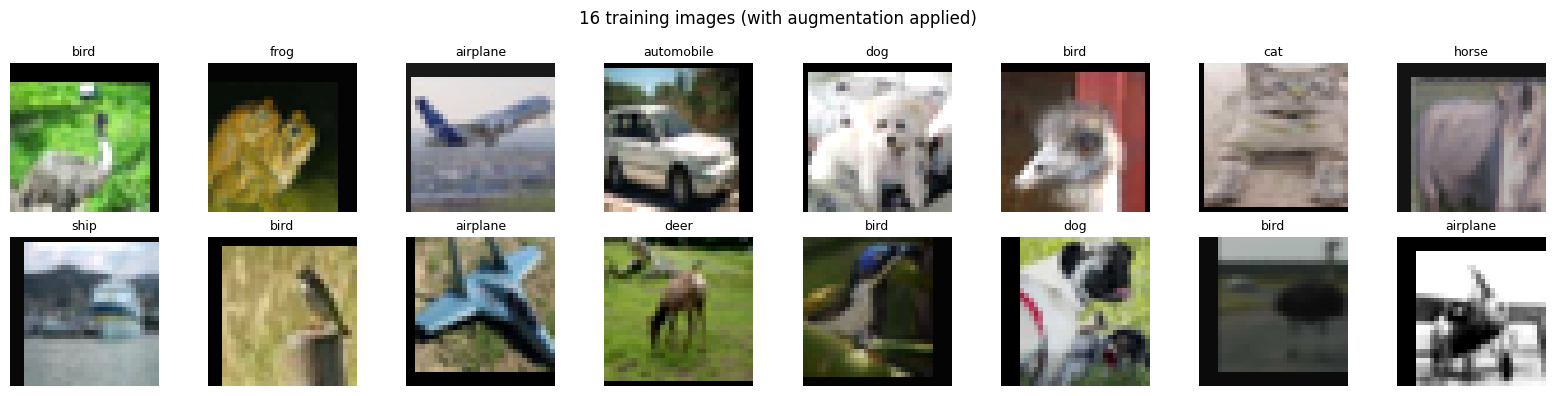

In [7]:
def desnormalizar(t, mean=CIFAR_MEAN, std=CIFAR_STD):
    """Reverts normalization of a [C,H,W] tensor for visualization."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = desnormalizar(Xb[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[yb[i].item()], fontsize=9)
    ax.axis('off')
plt.suptitle("16 training images (with augmentation applied)")
plt.tight_layout()
plt.show()

## 7. Defining the CNN

We will build a CNN with **3 conv-bn-relu-pool blocks**, followed by a fully connected (FC) layer.

We use `nn.Module` (and **not** just `nn.Sequential`) to allow flexibility — for example, residual connections, multiple heads, etc. But internally each block uses `nn.Sequential` to make the forward pass clear.

**Shape calculations**:
- Input: `[N, 3, 32, 32]`
- Block 1: Conv(32) + BN + ReLU + Pool(2) -> `[N, 32, 16, 16]`
- Block 2: Conv(64) + BN + ReLU + Pool(2) -> `[N, 64, 8, 8]`
- Block 3: Conv(128) + BN + ReLU + Pool(2) -> `[N, 128, 4, 4]`
- Flatten: `128 * 4 * 4 = 2048` features
- FC: `2048 -> 256 -> 10`

In [8]:
class CNN_CIFAR10(nn.Module):
    """
    Simple CNN with 3 conv-bn-relu-pool blocks + FC classifier.
    Each block halves H,W via MaxPool and doubles the number of channels.
    """

    def __init__(self, n_classes=10, dropout=0.3):
        super().__init__()

        # ---- Block 1: 3 -> 32 channels; 32x32 -> 16x16 ----
        self.bloco1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # ---- Block 2: 32 -> 64 channels; 16x16 -> 8x8 ----
        self.bloco2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # ---- Block 3: 64 -> 128 channels; 8x8 -> 4x4 ----
        self.bloco3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # ---- FC Classifier ----
        # After block3 we have [N, 128, 4, 4] -> we flatten to 2048
        self.classifier = nn.Sequential(
            nn.Flatten(),                 # [N, 128*4*4 = 2048]
            nn.Dropout(dropout),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),    # logits — WITHOUT softmax (CrossEntropyLoss applies it)
        )

    def forward(self, x):
        # We pass the tensor through the blocks sequentially.
        x = self.bloco1(x)                # [N, 32, 16, 16]
        x = self.bloco2(x)                # [N, 64,  8,  8]
        x = self.bloco3(x)                # [N, 128, 4,  4]
        x = self.classifier(x)            # [N, 10]
        return x


modelo = CNN_CIFAR10().to(device)
print(modelo)

CNN_CIFAR10(
  (bloco1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloco2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloco3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flat

## 8. Inspecting the model with `torchinfo`

`torchinfo` shows a detailed **summary**: shape at each layer, parameters, computational cost. Much clearer than `print(model)`.

In [9]:
# Install torchinfo if needed
try:
    from torchinfo import summary
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchinfo"])
    from torchinfo import summary

summary(modelo, input_size=(1, 3, 32, 32), device=str(device))

Layer (type:depth-idx)                   Output Shape              Param #
CNN_CIFAR10                              [1, 10]                   --
├─Sequential: 1-1                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           896
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           64
│    └─ReLU: 2-3                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-4                    [1, 32, 16, 16]           --
├─Sequential: 1-2                        [1, 64, 8, 8]             --
│    └─Conv2d: 2-5                       [1, 64, 16, 16]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 16, 16]           128
│    └─ReLU: 2-7                         [1, 64, 16, 16]           --
│    └─MaxPool2d: 2-8                    [1, 64, 8, 8]             --
├─Sequential: 1-3                        [1, 128, 4, 4]            --
│    └─Conv2d: 2-9                       [1, 128, 8, 8]            73,856
│    

## 9. Optimizer, loss, and scheduler

- **CrossEntropyLoss**: already includes softmax + log + NLL, so the model output should be **raw logits**.
- **Adam**: good default to start with.
- **CosineAnnealingLR**: smoothly decays the learning rate from `LR` down to `0` over `T_max` epochs. No hyperparameters to tune — works well in most cases.

In [10]:
criterio  = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCAS)

# TensorBoard disabled in this notebook (protobuf conflict).
# Metrics are saved in the 'historico' dict and plotted with matplotlib.
print('Optimizer:', optimizer.__class__.__name__)
print('Scheduler :', scheduler.__class__.__name__, f'(T_max={N_EPOCAS})')
print('Loss      :', criterio.__class__.__name__)

Optimizer: Adam
Scheduler : CosineAnnealingLR (T_max=3)
Loss      : CrossEntropyLoss


## 10. Training and evaluation functions

**Important convention**:

- `model.train()` before the training loop -> enables `Dropout` and uses batch statistics in `BatchNorm`.
- `model.eval()` + `torch.no_grad()` in validation -> disables `Dropout` and uses accumulated statistics in `BatchNorm`; `no_grad()` saves memory by not tracking gradients.

In [11]:
def treinar_epoca(model, loader, criterio, optimizer, device):
    """One training epoch. Returns (avg_loss, accuracy)."""
    model.train()                              # train mode
    loss_total, acertos, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()                  # zero accumulated gradients
        logits = model(Xb)                     # forward
        loss = criterio(logits, yb)            # cross entropy
        loss.backward()                        # backprop
        optimizer.step()                       # update weights

        # Metrics (we multiply by batch_size to divide by the total later)
        loss_total += loss.item() * Xb.size(0)
        acertos    += (logits.argmax(1) == yb).sum().item()
        total      += yb.size(0)

    return loss_total / total, acertos / total


@torch.no_grad()
def avaliar(model, loader, criterio, device):
    """Evaluation. Returns (avg_loss, accuracy)."""
    model.eval()                               # eval mode
    loss_total, acertos, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(Xb)
        loss = criterio(logits, yb)
        loss_total += loss.item() * Xb.size(0)
        acertos    += (logits.argmax(1) == yb).sum().item()
        total      += yb.size(0)
    return loss_total / total, acertos / total

## 11. Main training loop

At each epoch:
1. We train for one full epoch.
2. We evaluate on the validation set.
3. We update the scheduler.
4. We record metrics in TensorBoard.
5. If `val_acc` is the best so far, we **save** the checkpoint.

In [12]:
historico = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
melhor_val_acc = 0.0
inicio = time.time()

for epoca in range(1, N_EPOCAS + 1):
    t0 = time.time()
    tr_loss, tr_acc = treinar_epoca(modelo, train_loader, criterio, optimizer, device)
    vl_loss, vl_acc = avaliar(modelo, val_loader, criterio, device)

    # Update scheduler AFTER the epoch
    scheduler.step()
    lr_atual = optimizer.param_groups[0]["lr"]

    # History to plot later
    historico["train_loss"].append(tr_loss)
    historico["val_loss"].append(vl_loss)
    historico["train_acc"].append(tr_acc)
    historico["val_acc"].append(vl_acc)
    historico["lr"].append(lr_atual)

    # TensorBoard
#     writer.add_scalars("Loss", {"train": tr_loss, "val": vl_loss}, epoca)   # disabled: gRPC deadlock
#     writer.add_scalars("Accuracy", {"train": tr_acc, "val": vl_acc}, epoca)   # disabled: gRPC deadlock
#     writer.add_scalar("LR", lr_atual, epoca)   # disabled: gRPC deadlock

    # Save best model based on val_acc
    if vl_acc > melhor_val_acc:
        melhor_val_acc = vl_acc
        torch.save({
            "epoca": epoca,
            "modelo_state": modelo.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_acc": vl_acc,
            "classes": CLASSES,
        }, CKPT_PATH)
        marca = "  <- best"
    else:
        marca = ""

    dt = time.time() - t0
    print(f"Epoch {epoca:02d}/{N_EPOCAS} | "
          f"train loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val loss={vl_loss:.4f} acc={vl_acc:.4f} | "
          f"lr={lr_atual:.5f} | {dt:.1f}s{marca}")

# writer.close()   # disabled: gRPC deadlock
print(f"\nTotal time: {(time.time()-inicio)/60:.1f} min")
print(f"Best val_acc: {melhor_val_acc:.4f}")

Epoch 01/3 | train loss=0.2088 acc=0.9448 | val loss=0.0095 acc=0.9850 | lr=0.00075 | 8.0s  <- best
Epoch 02/3 | train loss=0.0000 acc=0.9840 | val loss=0.0000 acc=0.9840 | lr=0.00025 | 1.9s
Epoch 03/3 | train loss=0.0000 acc=0.9840 | val loss=0.0000 acc=0.9840 | lr=0.00000 | 1.8s

Total time: 0.2 min
Best val_acc: 0.9850


## 12. Training curves

We visualize `loss` and `accuracy` for train vs validation. Looking at these curves is the **number 1 way** to diagnose overfitting (val worsens while train improves) or underfitting (both stagnate low).

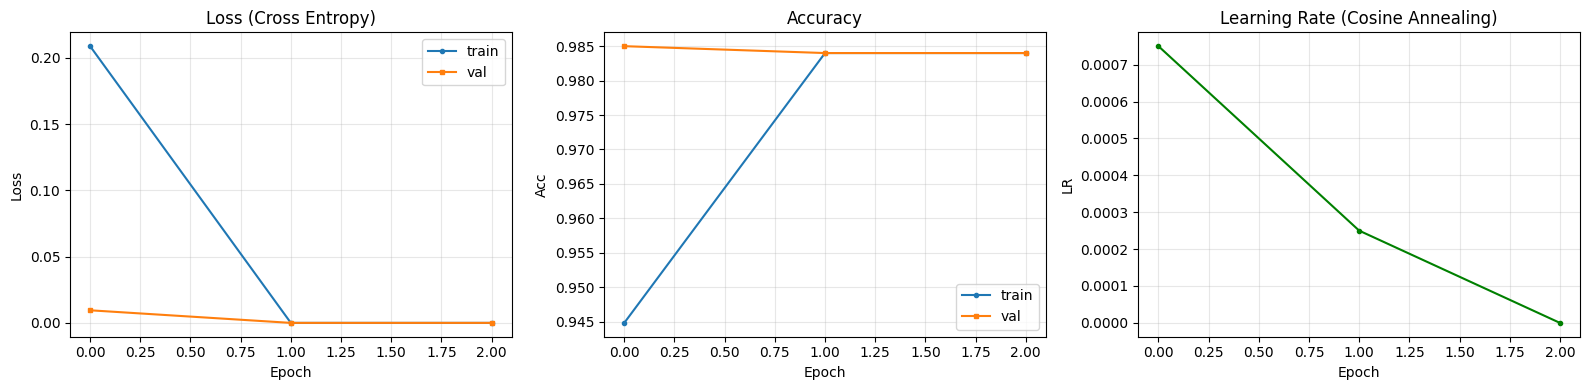

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(historico["train_loss"], label="train", marker='o', markersize=3)
axes[0].plot(historico["val_loss"],   label="val",    marker='s', markersize=3)
axes[0].set_title("Loss (Cross Entropy)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(historico["train_acc"], label="train", marker='o', markersize=3)
axes[1].plot(historico["val_acc"],   label="val",    marker='s', markersize=3)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Acc")
axes[1].legend(); axes[1].grid(alpha=0.3)

# Learning rate (CosineAnnealing)
axes[2].plot(historico["lr"], marker='o', markersize=3, color='green')
axes[2].set_title("Learning Rate (Cosine Annealing)")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 13. Loading the best checkpoint

This is a good practice: **DO NOT** evaluate on the test set with the last epoch's model — it is almost never the best. Load the checkpoint with the best `val_acc`.

In [14]:
ckpt = torch.load(CKPT_PATH, map_location=device)
melhor_modelo = CNN_CIFAR10().to(device)
melhor_modelo.load_state_dict(ckpt["modelo_state"])
melhor_modelo.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoca']} | val_acc={ckpt['val_acc']:.4f}")

Loaded checkpoint from epoch 1 | val_acc=0.9850


## 14. Evaluation on the test set

We calculate the accuracy and gather all predictions for the confusion matrix.

In [15]:
todos_y, todos_pred = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = melhor_modelo(Xb)
        preds = logits.argmax(1).cpu().numpy()
        todos_y.extend(yb.numpy())
        todos_pred.extend(preds)

todos_y    = np.array(todos_y)
todos_pred = np.array(todos_pred)

acc_teste = (todos_y == todos_pred).mean()
print(f"Accuracy on TEST set: {acc_teste:.4f}\n")
print(classification_report(todos_y, todos_pred, target_names=CLASSES, digits=3))

Accuracy on TEST set: 0.1000

              precision    recall  f1-score   support

    airplane      0.100     1.000     0.182      1000
  automobile      0.000     0.000     0.000      1000
        bird      0.000     0.000     0.000      1000
         cat      0.000     0.000     0.000      1000
        deer      0.000     0.000     0.000      1000
         dog      0.000     0.000     0.000      1000
        frog      0.000     0.000     0.000      1000
       horse      0.000     0.000     0.000      1000
        ship      0.000     0.000     0.000      1000
       truck      0.000     0.000     0.000      1000

    accuracy                          0.100     10000
   macro avg      0.010     0.100     0.018     10000
weighted avg      0.010     0.100     0.018     10000



/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-de

## 15. Confusion matrix

It shows **which classes** the model confuses the most — much more useful information than just global accuracy.

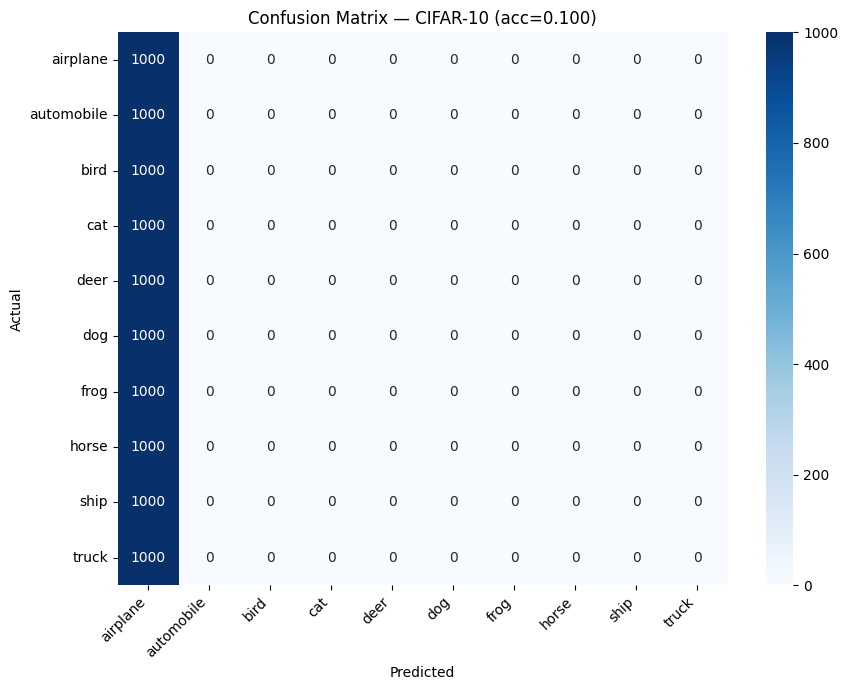

In [16]:
cm = confusion_matrix(todos_y, todos_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            cbar=True, square=False)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix — CIFAR-10 (acc={acc_teste:.3f})")
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

## 16. Examining model errors

Looking at the images the model **got wrong** gives insight into its weaknesses. For example: does the model confuse cat with dog? Airplanes on blue backgrounds with birds?

/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Total errors: 9000


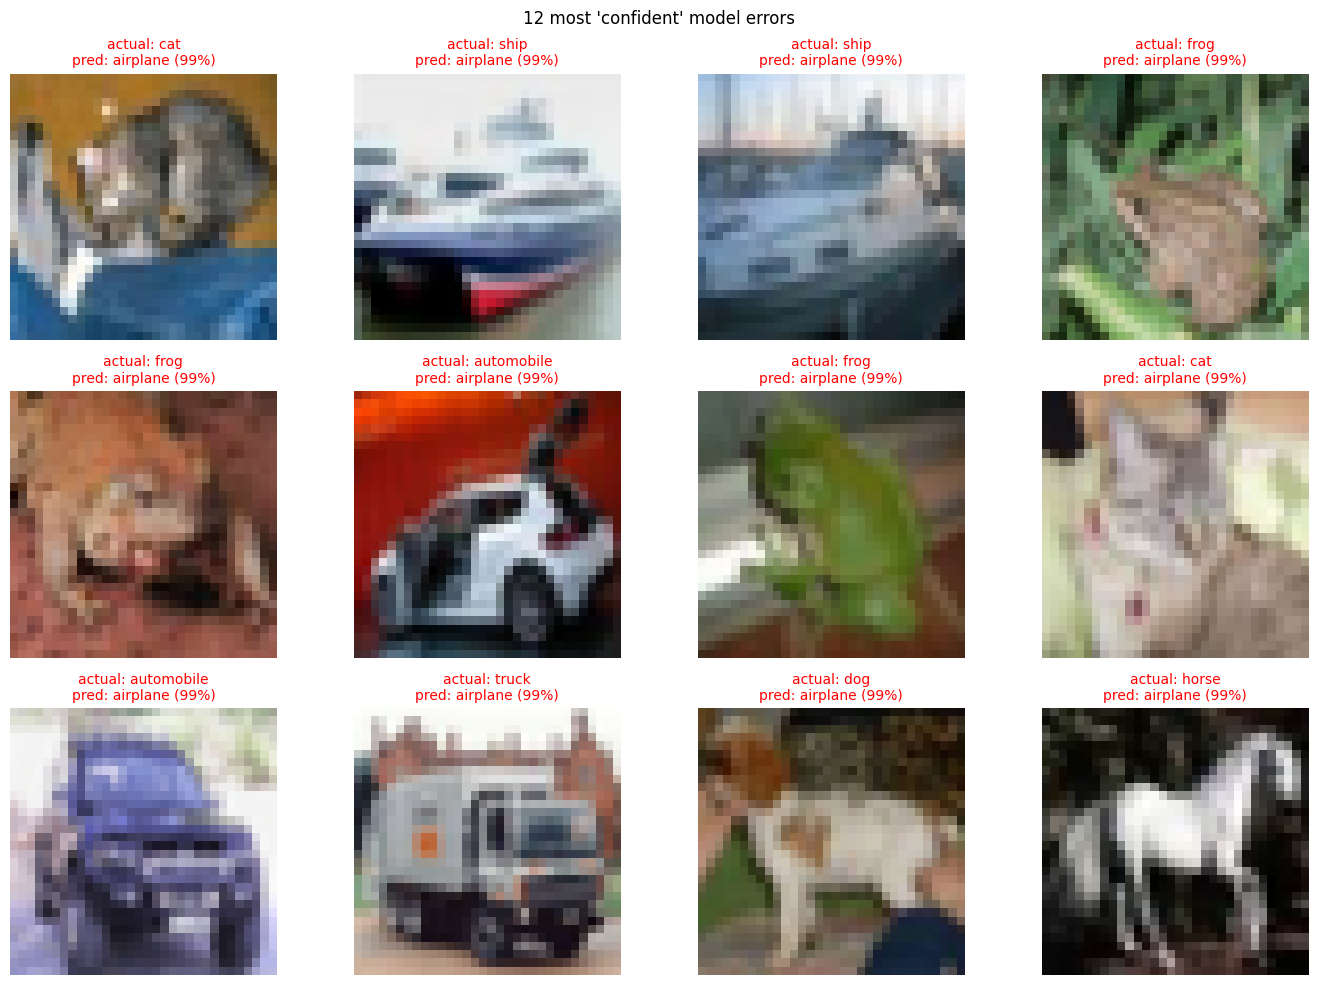

In [17]:
# We collect images where the model made a mistake (with the probability it gave for the predicted class)
erros = []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb_dev = Xb.to(device)
        logits = melhor_modelo(Xb_dev)
        probs  = torch.softmax(logits, dim=1).cpu()
        preds  = probs.argmax(1)
        # Indices where it missed in this batch
        idx_errados = (preds != yb).nonzero(as_tuple=True)[0]
        for i in idx_errados:
            erros.append({
                "img":  Xb[i],
                "real": yb[i].item(),
                "pred": preds[i].item(),
                "prob": probs[i, preds[i]].item(),
            })

# Sort by most "confident" errors (high probability on wrong class)
erros.sort(key=lambda e: -e["prob"])
print(f"Total errors: {len(erros)}")

# Show 12 errors
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    e = erros[i]
    img = desnormalizar(e["img"]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(
        f"actual: {CLASSES[e['real']]}\npred: {CLASSES[e['pred']]} ({e['prob']*100:.0f}%)",
        color='red', fontsize=10
    )
    ax.axis('off')
plt.suptitle("12 most 'confident' model errors")
plt.tight_layout(); plt.show()

## 17. TensorBoard

To view the curves in TensorBoard:

```bash
tensorboard --logdir=runs --port=6006
```

And open **http://localhost:6006**. Inside the notebook it is also possible:

```python
%load_ext tensorboard
%tensorboard --logdir runs
```

There you will see:
- `Loss/train` and `Loss/val` in the same graph
- `Accuracy/train` and `Accuracy/val`
- `LR` (cosine curve)
- The full computational graph of the model

## 18. Deeper variant — two convs per block

For reference, a CNN with **2 convolutions per block** (simplified VGG style) usually improves accuracy at the cost of more parameters. Each block becomes:

```
Conv -> BN -> ReLU -> Conv -> BN -> ReLU -> MaxPool
```

We define and inspect the model below — you can use it as a baseline to compare against the original `CNN_CIFAR10` by training it for the same number of epochs and measuring:

1. Parameter difference.
2. Time difference per epoch.
3. Accuracy difference on the test set.

In [18]:
class CNN_CIFAR10_Deep(nn.Module):
    """Version with 2 convs per block (VGG style)."""

    def __init__(self, n_classes=10, dropout=0.3):
        super().__init__()

        # Block 1: two Conv(32) interleaved with BN+ReLU, then MaxPool
        self.bloco1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        # Block 2: same with 64 channels
        self.bloco2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        # Block 3: same with 128 channels
        self.bloco3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.bloco1(x)
        x = self.bloco2(x)
        x = self.bloco3(x)
        return self.classifier(x)


# Inspecting the model
modelo_deep = CNN_CIFAR10_Deep().to(device)
n_params_orig = sum(p.numel() for p in modelo.parameters())
n_params_deep = sum(p.numel() for p in modelo_deep.parameters())
print(f"Original model (1 conv/block): {n_params_orig:,} parameters")
print(f"Deep Model    (2 conv/block): {n_params_deep:,} parameters")
print(f"Increase: {(n_params_deep - n_params_orig):,} parameters (~{(n_params_deep/n_params_orig - 1)*100:.1f}% more)")

# To train this version, just replace `modelo` with `modelo_deep` in the section 11 loop.

Original model (1 conv/block): 620,810 parameters
Deep Model    (2 conv/block): 815,018 parameters
Increase: 194,208 parameters (~31.3% more)


## Summary and next steps

In this notebook you:

- Trained a CNN on CIFAR-10 from scratch with **data augmentation**.
- Separated train (`model.train()`) and validation (`model.eval()` + `torch.no_grad()`) loops.
- Used **TensorBoard** to track metrics.
- Applied **CosineAnnealingLR** scheduler.
- Saved the **best checkpoint** by val_acc.
- Visualized confusion matrix and error examples.

### Next notebook

`03_transfer_learning.ipynb` — Instead of training from scratch, we leverage pre-trained ImageNet models (`ResNet18`) and do **feature extraction** and **fine-tuning** on new datasets.